# DAY 154 - End-To-End NLP Pipeline
@A.IPYNB

# Building the Production Pipeline: End-to-End NLP

### The Pipeline Concept
In the real world, the model is just one small box in the middle of a complex system. An end-to-end pipeline handles the flow of data from raw chaos to actionable insight.



### The Stages
1.  **Ingestion:** Loading raw, potentially messy data.
2.  **Tokenization:** Converting text into machine-readable IDs (The Translator).
3.  **Modeling:** Fine-tuning a pre-trained Transformer (DistilBERT).
4.  **Evaluation:** Using Confusion Matrices to diagnose *where* the model fails.
5.  **Inference:** Wrapping the model in a production-ready function.

### The Model: DistilBERT
We use **DistilBERT**, a smaller, faster, cheaper version of BERT. It retains 97% of BERT's performance but runs 60% faster—perfect for production pipelines.

In [ ]:
# @title 1. Data Ingestion
!pip install -q transformers datasets evaluate scikit-learn matplotlib

from datasets import load_dataset
import pandas as pd

# We'll load the "AG News" dataset (Standard benchmark for news classification)
# 4 Classes: World (0), Sports (1), Business (2), Sci/Tech (3)
dataset = load_dataset("ag_news")

# We'll convert to Pandas just for a quick visual inspection (Human Verification step)
df = pd.DataFrame(dataset['train'])
print(f"Dataset Size: {len(df)} samples")
print("\nSample Headline:")
print(df.iloc[0]['text'])
print(f"Label: {df.iloc[0]['label']} (World)")

Dataset Size: 120000 samples

Sample Headline:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 2 (World)


### Why not "Clean" the text?
In the old days (LSTM/RNN), we removed stop words ("the", "is") and lowercase everything.
**With Transformers, we DON'T do that.**
BERT relies on context. "To be or not to be" is entirely stop words, but it has deep meaning. Removing them destroys the signal.

Instead, our preprocessing is **Tokenization**: Mapping words to the specific vocabulary IDs the model learned during pre-training.

In [ ]:
# @title 2. The Tokenization Pipe
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)
dataset_encoded = dataset.map(tokenize, batched=True, batch_size=None)
dataset_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Data Tokenized and Formatted.")

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Data Tokenized and Formatted.


In [ ]:
# @title 3. Initialize the Model
from transformers import AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = 4
label_names = ["World", "Sports", "Business", "Sci/Tech"]

# We'll load DistilBERT with a custom classification head on top (num_labels=4)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device)

print(f"Model loaded on {device}. Ready to fine-tune.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cuda. Ready to fine-tune.


In [ ]:
# @title 4. Training Loop
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

batch_size = 64
logging_steps = len(dataset_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-agnews"

training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=False,
    log_level="error"
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset_encoded["train"],
    eval_dataset=dataset_encoded["test"],
    tokenizer=tokenizer
)

trainer.train()

/tmp/ipython-input-1749762118.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: drishyastudio134 (drishyastudio134-kk) to https://api.wandb.ai. Use `wandb login --relogin` to 

Step,Training Loss
1875,0.233200


Step,Training Loss
1875,0.233200
3750,0.140100


TrainOutput(global_step=3750, training_loss=0.18667262369791668, metrics={'train_runtime': 7658.0031, 'train_samples_per_second': 31.34, 'train_steps_per_second': 0.49, 'total_flos': 2.353450067136e+16, 'train_loss': 0.18667262369791668, 'epoch': 2.0})

### The Confusion Matrix
Accuracy numbers hide the truth. To understand a pipeline, you need to know *how* it fails.
Does it confuse **Business** with **Sci/Tech**? (Common, because tech companies are businesses).
Does it confuse **Sports** with **World**? (Unlikely).

We visualizes this with a Confusion Matrix.

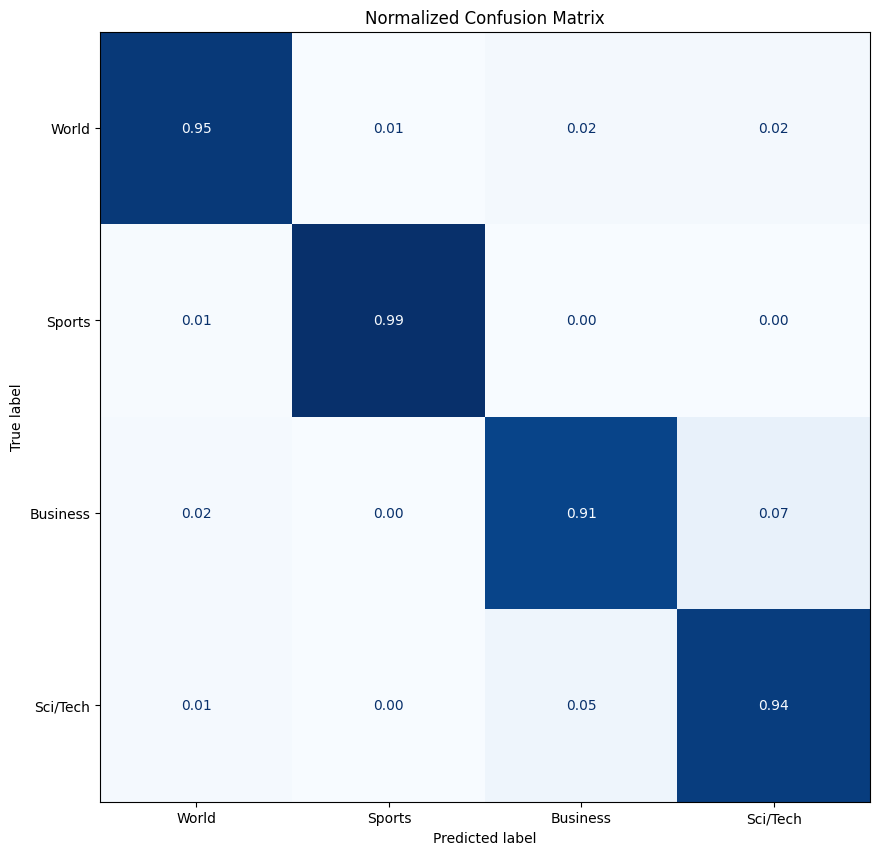

In [ ]:
# @title 5. Visualizing Errors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_output = trainer.predict(dataset_encoded["test"])
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = dataset_encoded["test"]["label"]

cm = confusion_matrix(y_true, y_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalized Confusion Matrix")
plt.show()

### The Final Artifact
The pipeline isn't done until you can input a raw string and get a clean answer.
We wrap the model and tokenizer into a simple `classify_text` function that acts as our API.

In [ ]:
# @title 6. Inference Function
def classify_text(text):
    # 1. Tokenize Input (Handle raw string)
    inputs = tokenizer(text, return_tensors="pt").to(device)

    # 2. Forward Pass (Get logits)
    with torch.no_grad():
        logits = model(**inputs).logits

    # 3. Post-processing (Get class ID and confidence)
    predicted_class_id = logits.argmax().item()
    confidence = torch.softmax(logits, dim=1).max().item()

    # 4. Map to Label
    predicted_label = label_names[predicted_class_id]

    return predicted_label, confidence

headline_1 = "Nvidia stock soars as AI demand increases."
headline_2 = "Astronomers discover a new black hole near the galaxy center."

print(f"Input: {headline_1}\nResult: {classify_text(headline_1)}\n")
print(f"Input: {headline_2}\nResult: {classify_text(headline_2)}\n")

Input: Nvidia stock soars as AI demand increases.
Result: ('Sci/Tech', 0.5035901069641113)

Input: Astronomers discover a new black hole near the galaxy center.
Result: ('Sci/Tech', 0.9108883142471313)



### Conclusion
You have built a full cycle:
1.  **Ingestion:** Automated download of AG News.
2.  **Processing:** Context-aware tokenization.
3.  **Training:** Fine-tuning a Transformer.
4.  **Diagnostics:** Validating with a Confusion Matrix.
5.  **Deployment:** A function ready for an API wrapper (FastAPI/Flask).

**The Strategic Win:**
This pipeline is **model-agnostic**.

You can swap `distilbert-base-uncased` for `roberta-large` or `bert-base-multilingual` by changing *one line of code*, and the entire pipeline will still work.
You have built a reusable engine for text classification.